# 05 — Classical: Exact Model with PuLP and CBC

The greedy in notebook 04 decides one order at a time and never goes back. Here we solve the same
problem **exactly**, looking at all 472 orders together, with a standard MILP solver.

This gives the best answer that exists. The distance between it and the greedy tells us how much the
greedy leaves behind.

This notebook runs on its own. It reads nothing from other notebooks and it saves nothing.

## 1. Setup

PuLP brings its own CBC solver, so there is nothing else to install.

In [1]:
import sys, subprocess
try:
    import pulp
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pulp"], check=True)
    import pulp
print("pulp ready")

pulp ready


## 1. Setup

This notebook runs on its own. It reads the data files, does its own work, and prints the results.
It does not upload anything, and it does not save any files.

Set `DATA_DIR` below to the folder that holds the CSV files. If the folder is somewhere under the
current directory, the notebook finds it by itself.

In [2]:
#from google.colab import drive
#drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os, glob, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# Put the path to your data folder here, or leave it as None to search for it.
DATA_DIR = None

def find_data(start=DATA_DIR):
    """Return the folder that holds input_order data.csv."""
    if start and os.path.isfile(os.path.join(start, "input_order data.csv")):
        return start
    for hit in glob.glob("**/input_order data.csv", recursive=True):
        return os.path.dirname(hit)          # first match wins
    raise FileNotFoundError(
        "Could not find 'input_order data.csv'. Set DATA_DIR to the folder that holds the CSV files.")

IN = find_data()                              # folder with the 5 input files
ROOT = os.path.dirname(IN) if os.path.basename(IN) == "input data" else IN
print("input folder :", IN)

input folder : drive/MyDrive/DOM/dom_extract/Nestle - WISER WQ26 DOM-data [SHARED]/DOM-data/input data


## 2. Read the data

Five input files. Two output files come from the earlier model run; we use them only to check our
own numbers, never as input.

In [4]:
orders = pd.read_csv(f"{IN}/input_order data.csv")            # one row per order and SKU
cap    = pd.read_csv(f"{IN}/input_capacity_planning.csv")     # daily stock per DC and SKU
dock   = pd.read_csv(f"{IN}/input_dock_capacity.csv")         # daily dock slots per DC
ship   = pd.read_csv(f"{IN}/input_shipping_cost_data.csv")    # cost per DC to zip lane
thru   = pd.read_csv(f"{IN}/input_throughput_capacity.csv")   # daily pick work per DC

def read_output(name):
    """The two output files may sit beside the input folder or one level up."""
    for p in [f"{ROOT}/{name}", f"{IN}/{name}", f"{ROOT}/../{name}"]:
        if os.path.isfile(p):
            return pd.read_csv(p)
    return None

poc_ord = read_output("Output_order_level_data.csv")          # check only
poc_sku = read_output("output_order_sku_level_data.csv")      # check only

for n, d in [("orders", orders), ("capacity", cap), ("dock", dock),
             ("shipping", ship), ("throughput", thru)]:
    print(f"{n:11s} {d.shape}")

orders      (25193, 39)
capacity    (377504, 23)
dock        (480, 13)
shipping    (12922, 7)
throughput  (530, 7)


## 3. Prepare the orders

Four small steps: parse the dates, put every line into cases, work out a price per case, and roll the
lines up to one row per order.

In [5]:
orders["PGI"] = pd.to_datetime(orders["transportationplanningdate"], format="%m/%d/%y")  # ship day
orders["RDD"] = pd.to_datetime(orders["RequestedDeliveryDate"],      format="%m/%d/%y")  # due day
orders["IsInvAvail"] = orders["IsInvAvail"].astype(str).str.strip().str.upper()

# Lines measured in pallets become cases, so everything is in the same unit.
orders["cases"] = np.where(orders["ProductPlanningUnitOfMeasure"].eq("PL"),
                           orders["OrderedQty_converted"] * orders["ProductCasesPerPallet"],
                           orders["OrderedQty_converted"]).astype(float)

# Price per case lets us rebuild revenue from the cases we actually fill.
orders["price_per_case"] = np.where(orders["cases"] > 0,
                                    orders["Order_SKU_Revenue"] / orders["cases"], 0.0)
orders["cpp"] = orders["ProductCasesPerPallet"].replace(0, np.nan).fillna(1).astype(float)

# One row per order.
head = orders.groupby("Group_Flag").agg(
    default_dc=("Plant", "first"),            # the DC it uses today
    pgi=("PGI", "first"),                     # planned ship day
    rdd=("RDD", "first"),                     # customer due day
    zipc=("ZipCode", "first"),                # ship-to zip, for the freight cost
    prio=("DeliveryPriority", "min"),         # 8 = protected order, 99 = normal
    revenue=("Order_SKU_Revenue", "sum"),
    ordered_cases=("cases", "sum"),
    frt=("FillRateThreshold", "first"),       # fill % below which a penalty starts
    ppc=("Penaltyforpotentialcuts", "first"), # penalty rate on the missing value
).reset_index()
head[["frt", "ppc"]] = head[["frt", "ppc"]].fillna(0.0)
head["threshold_cases"] = head["frt"] * head["ordered_cases"]

HEAD  = head.set_index("Group_Flag").to_dict("index")
LINES = {gf: [(int(r.MaterialNumber), float(r.cases), float(r.price_per_case), float(r.cpp))
              for r in g.itertuples(index=False)]
         for gf, g in orders.groupby("Group_Flag", sort=False)}

print("orders:", len(head), "| SKUs:", orders.MaterialNumber.nunique(),
      "| DCs:", orders.Plant.nunique())

orders: 1109 | SKUs: 1110 | DCs: 8


## 4. Find the focus orders

An order needs a decision for one of two reasons. Either it is short of stock at its own DC, or it
ships on a day when that DC has no dock slot left. Everything else is fine and stays where it is.

In [6]:
# Short of stock: any line of the order has IsInvAvail = N.
roll   = orders.groupby("Group_Flag")["IsInvAvail"].apply(lambda s: (s == "Y").all())
SUFF   = set(roll[roll].index)
INSUFF = set(roll[~roll].index)

# No dock left on the planned ship day.
dock["Date"] = pd.to_datetime(dock["Date"], format="%m/%d/%y")
zero_days = set(map(tuple, dock.loc[dock["Dock_Remaining"] == 0, ["Plant", "Date"]]
                              .drop_duplicates().values))
ADDED = {gf for gf, h in HEAD.items()
         if (h["default_dc"], h["pgi"]) in zero_days} & SUFF

FOCUS = sorted(INSUFF | ADDED)                        # the orders the model decides
CLEAN_ORDERS = sorted(set(HEAD) - set(FOCUS))         # the orders that stay put

print(f"{len(INSUFF)} short of stock + {len(ADDED)} with no dock = {len(FOCUS)} focus orders")
print(f"{len(CLEAN_ORDERS)} orders are fine and stay where they are")

447 short of stock + 25 with no dock = 472 focus orders
637 orders are fine and stay where they are


## 5. Build the stock, dock and capacity tables

Everything that changes by day sits on the same day grid, so "the next 5 days" is just a slice of an
array.

In [7]:
cap["DATE"] = pd.to_datetime(cap["DATE"])
DATES = pd.date_range(cap["DATE"].min(), cap["DATE"].max(), freq="D")
NT    = len(DATES)                                    # number of days
DIX   = {d: i for i, d in enumerate(DATES)}           # date -> position
DCS   = sorted(int(x) for x in orders["Plant"].unique())
DCIX  = {d: i for i, d in enumerate(DCS)}             # DC -> row number

# Free stock = opening stock minus what is already reserved.
cap["AV"] = cap["OpeningStock"] - cap["Total_Reserved_Qty"]
POOL0 = {}
for (d, s), g in cap[cap["LocationID"].isin(DCS)].groupby(["LocationID", "MaterialID"], sort=False):
    arr = np.zeros(NT)
    ix  = g["DATE"].map(DIX).dropna().astype(int).values
    arr[ix] = g["AV"].values[:len(ix)]
    POOL0[(int(d), int(s))] = arr                     # one stock line per DC and SKU

SKU_AT_DC = {}
for (d, s) in POOL0:
    SKU_AT_DC.setdefault(d, set()).add(s)             # which DC stocks which SKU

# Freight cost and distance for each DC to zip lane.
SHIP = {(int(r.Plant), int(r.TargetZip)): float(r.Shipping_Cost)
        for r in ship.itertuples(index=False)}
DIST = {(int(r.Plant), int(r.TargetZip)): float(r.Distance)
        for r in ship.itertuples(index=False)}

# Free dock slots. Two DCs have no rows at all, so we mark them "no data" and skip the check there.
DOCK0 = np.full((len(DCS), NT), np.nan)
for r in dock.itertuples(index=False):
    if r.Plant in DCIX and r.Date in DIX:
        DOCK0[DCIX[r.Plant], DIX[r.Date]] = max(0.0, float(r.Dock_Remaining))
DOCK_HAS = ~np.isnan(DOCK0)
DOCK0    = np.nan_to_num(DOCK0, nan=0.0)

# Pick capacity. The file gives usage only, so we take the highest usage as the limit.
thru["transportationplanningdate"] = pd.to_datetime(thru["transportationplanningdate"])
CP_CAP = thru.groupby("Plant")["util_case_picks"].max().to_dict()
PP_CAP = thru.groupby("Plant")["util_pallets"].max().to_dict()
CP0 = np.zeros((len(DCS), NT)); PP0 = np.zeros((len(DCS), NT))
for d in DCS:
    CP0[DCIX[d], :] = CP_CAP.get(d, 0.0)
    PP0[DCIX[d], :] = PP_CAP.get(d, 0.0)
for r in thru.itertuples(index=False):
    if r.Plant in DCIX and r.transportationplanningdate in DIX:
        i, j = DCIX[r.Plant], DIX[r.transportationplanningdate]
        CP0[i, j] = max(0.0, CP_CAP[r.Plant] - r.util_case_picks)
        PP0[i, j] = max(0.0, PP_CAP[r.Plant] - r.util_pallets)

print("days:", NT, "| DCs:", DCS, "| DC-SKU stock lines:", len(POOL0))

days: 32 | DCs: [5083, 5385, 5410, 5420, 5490, 5620, 5641, 5773] | DC-SKU stock lines: 11550


## 6. The rules and the objective

The business rules from the project documents, written as small functions.

**Objective = Revenue − Penalty − Shipping cost**

| Rule | What it means |
|---|---|
| C1 | One order goes to one DC only |
| C2 | You cannot fill more than what was ordered |
| C3 | Stock must be there, and must still cover the next 5 days |
| C4 | Move only if the fill rises 5 points **and** 100 cases |
| C5 | Case picks and pallet picks must fit the DC limit that day |
| C6 | One dock slot per order, and docks are limited |
| C7 | A penalty applies only if filled cases fall under the order threshold |

In [8]:
CFG = dict(
    MIN_FILL_LIFT_PP   = 0.05,   # C4: the fill must rise 5 points
    MIN_CASE_LIFT      = 100.0,  # C4: and at least 100 cases
    FORWARD_COVER_DAYS = 5,      # C3: stock must last 5 more days
    LEAD_TIME_MILES    = 500.0,  # one transit day per 500 miles
    DOCKS_PER_ORDER    = 1,      # C6: one dock per order
    SAFETY_STOCK_FRAC  = 0.0,    # hold back stock elsewhere (sensitivity only)
    REQUIRE_OBJ_GAIN   = True,   # greedy only: move only if the money improves
)

def avail(P, d, s, t, window=0):
    """C3: how many cases we may take. With a window, the tightest day decides."""
    a = P.get((d, s))
    if a is None:
        return 0.0
    hi = min(NT, t + window + 1)
    return max(0.0, a[t:hi].min()) if hi > t else 0.0

def take(P, d, s, t, q):
    a = P.get((d, s))
    if a is not None and q > 0:
        a[t:] -= q                                  # gone from today and every later day

def give(P, d, s, t, q):
    a = P.get((d, s))
    if a is not None and q > 0:
        a[t:] += q                                  # put it back the same way

def evaluate(P, gf, d, t, window=0, reserve=0.0):
    """C2 and C3: how much of this order this DC can fill on this day."""
    fills, by, tot, rev = [], {}, 0.0, 0.0
    for s, dem, price, cpp in LINES[gf]:
        q = min(dem, avail(P, d, s, t, window) * (1.0 - reserve))   # never more than ordered
        fills.append((s, q, price, cpp)); by[s] = q; tot += q; rev += q * price
    return fills, by, tot, rev

def picks(fills):
    """C5: full pallets are pallet picks, the rest are case picks."""
    cp = pp = 0.0
    for _, q, _, cpp in fills:
        if q <= 0:
            continue
        full = math.floor(q / cpp); pp += full; cp += q - full * cpp
    return cp, pp

def penalty_of(gf, by, tot):
    """C7: no penalty if we reach the threshold, otherwise charge for what is missing."""
    h = HEAD[gf]
    if h["ppc"] <= 0 or tot >= h["threshold_cases"]:
        return 0.0
    return max(0.0, sum((dem - by.get(s, 0.0)) * price * h["ppc"]
                        for s, dem, price, _ in LINES[gf]))

def objective(rec):
    """Revenue minus penalty minus shipping."""
    return rec["revenue"] - rec["pen"] - rec["ship"]

def lead_time(d, z):
    dd = DIST.get((d, z))
    return None if dd is None else max(1, int(math.ceil(dd / CFG["LEAD_TIME_MILES"])))

def revised_pgi(gf, d):
    """A farther DC needs more transit time, so the ship day moves earlier."""
    h = HEAD[gf]; lt = lead_time(d, h["zipc"])
    if lt is None:
        return None, "no_lane"
    p = min(h["pgi"], h["rdd"] - pd.Timedelta(days=lt))
    while p.weekday() >= 5:                          # step back off Saturday and Sunday
        p -= pd.Timedelta(days=1)
    return (None, "pgi_out_of_horizon") if p not in DIX else (p, None)

def passes_gate(lift, ordered, cfg=CFG):
    """C4: the move must be worth making."""
    if lift < cfg["MIN_FILL_LIFT_PP"] * ordered:
        return "fail_5pct"
    if lift < cfg["MIN_CASE_LIFT"]:
        return "fail_100cases"
    return None

print("rules ready")

rules ready


## 7. Put every order at its own DC

This is the starting point. Protected orders (priority 8) go first, then the largest by revenue.
Each order takes its stock, so the next order sees what is left. This is also **Baseline 1**.

In [9]:
def stage_A():
    P = {k: v.copy() for k, v in POOL0.items()}      # work on a copy of the stock
    seq = head.sort_values(["prio", "revenue"], ascending=[True, False])["Group_Flag"]
    out = {}
    for gf in seq:
        h = HEAD[gf]; d = h["default_dc"]; t = DIX[h["pgi"]]
        fills, by, tot, rev = evaluate(P, gf, d, t, window=0)
        for s, q, _, _ in fills:
            take(P, d, s, t, q)                      # remove that stock for good
        cp, pp = picks(fills)
        out[gf] = dict(dc=d, t=t, fills=fills, by=by, filled=tot, revenue=rev, cp=cp, pp=pp,
                       pen=penalty_of(gf, by, tot), ship=SHIP.get((d, h["zipc"]), 0.0),
                       cof=tot / h["ordered_cases"] if h["ordered_cases"] else 0.0)
    return P, out

POOL_A, DEF = stage_A()
print("done:", len(DEF), "orders placed")

done: 1109 orders placed


## 8. The exact model

**Variables**

| name | type | meaning |
|---|---|---|
| `x[i,j]` | 0 or 1 | order `i` is served from DC `j` |
| `q[i,j,k]` | number ≥ 0 | cases of SKU `k` filled for order `i` at DC `j` |
| `z[i]` | 0 or 1 | order `i` reached its threshold, so no penalty |
| `pen[i]` | number ≥ 0 | the penalty charged on order `i` |

**Objective:** maximise `sum(price × q) − sum(pen) − sum(ship × x)`.

The filled cases are variables, not fixed numbers. This matters. If each option carried a fixed
quantity, the model could not describe a partial fill, and it would score *below* the greedy.

**The rules become linear constraints**, using the same numbers as the functions above.

In [10]:
def candidate_options(subset):
    """For each order: its own DC, plus every DC that stocks all its SKUs and can still
    make the delivery date."""
    cand = {}
    for g in subset:
        base = DEF[g]
        opts = [(base["dc"], base["t"], True)]        # staying put is always an option
        for d in DCS:
            if d == base["dc"]:
                continue
            if not all(s in SKU_AT_DC.get(d, set()) for s, _, _, _ in LINES[g]):
                continue
            p, err = revised_pgi(g, d)
            if err:
                continue
            opts.append((d, DIX[p], False))
        cand[g] = opts
    return cand

CAND = candidate_options(FOCUS)
print("orders:", len(CAND), "| options:", sum(len(v) for v in CAND.values()))

orders: 472 | options: 2295


In [11]:
def build_milp(subset, cand):
    W = CFG["FORWARD_COVER_DAYS"]

    # Stock these orders hand back when they leave their own DC.
    GIVE = {}
    for g in subset:
        r = DEF[g]
        for s, qty, _, _ in r["fills"]:
            if qty > 0:
                GIVE.setdefault((r["dc"], s), np.zeros(NT))[r["t"]:] += qty

    # Dock room: every order holds a slot, then the focus orders hand theirs back.
    dock_av = DOCK0.copy()
    for g, r in DEF.items():
        i, j = DCIX[r["dc"]], r["t"]
        if DOCK_HAS[i, j]:
            dock_av[i, j] -= CFG["DOCKS_PER_ORDER"]
    dock_av = np.maximum(0.0, dock_av)
    for g in subset:
        r = DEF[g]
        i, j = DCIX[r["dc"]], r["t"]
        if DOCK_HAS[i, j]:
            dock_av[i, j] += CFG["DOCKS_PER_ORDER"]

    prob = pulp.LpProblem("DOM", pulp.LpMaximize)

    x   = {(g, d): pulp.LpVariable(f"x_{g}_{d}", cat="Binary")
           for g in subset for d, _, _ in cand[g]}
    q   = {(g, d, s): pulp.LpVariable(f"q_{g}_{d}_{s}", lowBound=0, upBound=dem)
           for g in subset for d, _, _ in cand[g] for s, dem, _, _ in LINES[g] if dem > 0}
    z   = {g: pulp.LpVariable(f"z_{g}", cat="Binary") for g in subset if HEAD[g]["ppc"] > 0}
    pen = {g: pulp.LpVariable(f"pen_{g}", lowBound=0) for g in subset if HEAD[g]["ppc"] > 0}

    # objective: revenue - penalty - shipping
    prob += (pulp.lpSum(price * q[g, d, s] for g in subset for d, _, _ in cand[g]
                        for s, dem, price, _ in LINES[g] if dem > 0)
             - pulp.lpSum(pen.values())
             - pulp.lpSum(SHIP.get((d, HEAD[g]["zipc"]), 0.0) * x[g, d]
                          for g in subset for d, _, _ in cand[g]))

    for g in subset:                                   # C1: one order, one DC
        prob += pulp.lpSum(x[g, d] for d, _, _ in cand[g]) == 1

    for g in subset:                                   # C2: never more than ordered
        for d, _, _ in cand[g]:
            for s, dem, _, _ in LINES[g]:
                if dem > 0:
                    prob += q[g, d, s] <= dem * x[g, d]

    draws = {}                                         # C3: stock over the 5-day window
    for g in subset:
        for d, t, isdef in cand[g]:
            w = 0 if isdef else W
            for s, dem, _, _ in LINES[g]:
                if dem > 0:
                    draws.setdefault((d, s), []).append((q[g, d, s], t, w))
    for (d, s), items in draws.items():
        arr, giv = POOL_A.get((d, s)), GIVE.get((d, s))
        days = set()
        for _, t, w in items:
            days |= set(range(t, min(NT, t + w + 1)))
        for u in sorted(days):
            active = [v for v, t, w in items if t <= u <= t + w]
            if not active:
                continue
            rhs = (max(0.0, arr[u]) if arr is not None else 0.0) + (giv[u] if giv is not None else 0.0)
            prob += pulp.lpSum(active) <= rhs

    for g in subset:                                   # C4: the move must be worth it
        need = DEF[g]["filled"] + max(CFG["MIN_FILL_LIFT_PP"] * HEAD[g]["ordered_cases"],
                                      CFG["MIN_CASE_LIFT"])
        for d, _, isdef in cand[g]:
            if not isdef:
                prob += pulp.lpSum(q[g, d, s] for s, dem, _, _ in LINES[g] if dem > 0) \
                        >= need * x[g, d]

    pe = {}                                            # C5: pallet picks fit the day
    for g in subset:
        for d, t, isdef in cand[g]:
            if not isdef:
                pe.setdefault((d, t), []).append(g)
    for (d, t), gs in pe.items():
        i = DCIX[d]
        if sum(sum(dem / cpp for _, dem, _, cpp in LINES[g]) for g in gs) <= PP0[i, t]:
            continue                                   # cannot overflow, no row needed
        prob += (pulp.lpSum(q[g, d, s] / cpp for g in gs
                            for s, dem, _, cpp in LINES[g] if dem > 0)
                 - pulp.lpSum(len(LINES[g]) * x[g, d] for g in gs)) <= float(PP0[i, t])

    de = {}                                            # C6: one dock per order
    for g in subset:
        for d, t, _ in cand[g]:
            if DOCK_HAS[DCIX[d], t]:
                de.setdefault((d, t), []).append(x[g, d])
    for (d, t), vs in de.items():
        capacity = float(dock_av[DCIX[d], t])
        if len(vs) > capacity:
            prob += pulp.lpSum(vs) <= capacity

    for g in subset:                                   # C7: penalty below the threshold
        h = HEAD[g]
        if h["ppc"] <= 0:
            continue
        full = sum(dem * price for _, dem, price, _ in LINES[g]) * h["ppc"]
        prob += (pen[g] + h["ppc"] * pulp.lpSum(price * q[g, d, s] for d, _, _ in cand[g]
                                                for s, dem, price, _ in LINES[g] if dem > 0)
                 >= full * (1 - z[g]))
        prob += pulp.lpSum(q[g, d, s] for d, _, _ in cand[g]
                           for s, dem, _, _ in LINES[g] if dem > 0) >= h["threshold_cases"] * z[g]

    info = dict(nvars=len(x) + len(q) + len(z) + len(pen), nbin=len(x) + len(z),
                nrows=len(prob.constraints))
    return prob, x, q, info

import time
t0 = time.time()
prob, X, Q, info = build_milp(FOCUS, CAND)
print(f"built in {time.time() - t0:.1f}s")
print(f"variables: {info['nvars']:,} ({info['nbin']:,} binary) | rows: {info['nrows']:,}")

built in 6.8s
variables: 88,342 (2,594 binary) | rows: 148,663


## 9. Solve

`gapRel = 0` asks for the proven best answer, not just a good one. We record the wall-clock time,
because that is what the scaling discussion needs.

In [12]:
def solve(prob, time_limit=900):
    t0 = time.time()
    prob.solve(pulp.PULP_CBC_CMD(msg=0, timeLimit=time_limit, gapRel=0.0))
    return time.time() - t0, pulp.LpStatus[prob.status], pulp.value(prob.objective)

WALL, STATUS, SOLVER_OBJ = solve(prob)
print(f"status   : {STATUS}")
print(f"wall time: {WALL:.2f} s")
print(f"objective: {SOLVER_OBJ:,.2f}")

status   : Optimal
wall time: 74.99 s
objective: 46,295,828.48


## 10. Read the answer back

We turn the solver variables into the same per-order record the other methods produce, and score it
again with our own `objective()`. If the two agree, the model and the scorer are the same thing.

In [13]:
def metrics(res, label, runtime=None):
    """The same scorecard for every method, measured on the focus orders."""
    oc = sum(HEAD[g]["ordered_cases"] for g in FOCUS)
    fl = sum(res[g]["filled"] for g in FOCUS)
    return dict(scenario=label,
                objective_focus=sum(objective(res[g]) for g in FOCUS),
                objective_all=sum(objective(res[g]) for g in res),
                fill_rate=fl / oc, cases_filled=fl,
                orders_moved=sum(1 for g in FOCUS if res[g]["diverted"]),
                penalty_cost=sum(res[g]["pen"] for g in FOCUS),
                shipping_cost=sum(res[g]["ship"] for g in FOCUS),
                runtime_s=runtime)

def show(m):
    for k, v in m.items():
        print(f"{k:17s} {v:,.4f}" if isinstance(v, float) else f"{k:17s} {v}")


def decode(subset, cand, x, q):
    res = {}
    for g in subset:
        h = HEAD[g]
        for d, t, isdef in cand[g]:
            if (x[g, d].value() or 0.0) <= 0.5:
                continue
            by = {s: ((q[g, d, s].value() or 0.0) if (g, d, s) in q else 0.0)
                  for s, dem, _, _ in LINES[g]}
            fills = [(s, by.get(s, 0.0), price, cpp) for s, dem, price, cpp in LINES[g]]
            tot = sum(by.values())
            rev = sum(by[s] * price for s, dem, price, _ in LINES[g])
            cp, pp = picks(fills)
            res[g] = dict(dc=d, t=t, fills=fills, by=by, filled=tot, revenue=rev, cp=cp, pp=pp,
                          pen=penalty_of(g, by, tot), ship=SHIP.get((d, h["zipc"]), 0.0),
                          cof=tot / h["ordered_cases"] if h["ordered_cases"] else 0.0,
                          diverted=not isdef, chosen_dc=d, lift=tot - DEF[g]["filled"])
            break
    return res

MILP = decode(FOCUS, CAND, X, Q)
for g in CLEAN_ORDERS:
    MILP[g] = dict(DEF[g], diverted=False, chosen_dc=DEF[g]["dc"], lift=0.0)

rescored = sum(objective(MILP[g]) for g in FOCUS)
print(f"solver objective  : {SOLVER_OBJ:,.2f}")
print(f"our own scoring   : {rescored:,.2f}")
print(f"difference        : {SOLVER_OBJ - rescored:,.2f}  (solver rounding)")
print()
show(metrics(MILP, "Classical - exact MILP", round(WALL, 2)))

solver objective  : 46,295,828.48
our own scoring   : 46,295,828.48
difference        : 0.00  (solver rounding)

scenario          Classical - exact MILP
objective_focus   46,295,828.4766
objective_all     77,012,774.5543
fill_rate         0.9328
cases_filled      1,352,341.0000
orders_moved      66
penalty_cost      32,333.0557
shipping_cost     622,880.0000
runtime_s         74.9900


## 11. Check the answer obeys the rules

We push the answer back through the same checks the greedy uses. A solver satisfies a rule only to
its own tolerance, so we allow a thousandth of a case before calling something a breach.

In [14]:
TOL = 1e-3
bad, slack = [], []
for g in FOCUS:
    r, h = MILP[g], HEAD[g]
    dem_of = dict((a, b) for a, b, _, _ in LINES[g])
    for s, qty, _, _ in r["fills"]:
        if qty - dem_of[s] > TOL:
            bad.append((g, "filled more than ordered"))
    if r["diverted"]:
        if not all(s in SKU_AT_DC.get(r["dc"], set()) for s, _, _, _ in LINES[g]):
            bad.append((g, "SKU not stocked there"))
        need = max(CFG["MIN_FILL_LIFT_PP"] * h["ordered_cases"], CFG["MIN_CASE_LIFT"])
        slack.append(need - r["lift"])
        if need - r["lift"] > TOL:
            bad.append((g, "gate not met"))

print("orders checked :", len(FOCUS), " (moved:", len(slack), ")")
print("worst gate miss:", f"{max(slack):.6f} cases   <- solver rounding")
print("real breaches  :", len(bad) if bad else "none - all clear")

orders checked : 472  (moved: 66 )
worst gate miss: 0.000000 cases   <- solver rounding
real breaches  : none - all clear


## 12. Compare with the greedy

We run the greedy here too, so the comparison is on the same data in the same session.

In [15]:
def greedy_2A():
    cfg = CFG
    P = {k: v.copy() for k, v in POOL_A.items()}
    dk, cp_r, pp_r = DOCK0.copy(), CP0.copy(), PP0.copy()
    for gf, r in DEF.items():
        i, j = DCIX[r["dc"]], r["t"]
        if DOCK_HAS[i, j]:
            dk[i, j] = max(0.0, dk[i, j] - cfg["DOCKS_PER_ORDER"])
    res = {g: dict(DEF[g], diverted=False, chosen_dc=DEF[g]["dc"], lift=0.0) for g in DEF}
    for gf in sorted(FOCUS, key=lambda g: -HEAD[g]["revenue"]):
        h, base = HEAD[gf], DEF[gf]
        d0, t0 = base["dc"], base["t"]; best = None
        for d in DCS:
            if d == d0 or not all(s in SKU_AT_DC.get(d, set()) for s, _, _, _ in LINES[gf]):
                continue
            p, err = revised_pgi(gf, d)
            if err:
                continue
            t = DIX[p]
            fills, by, tot, rev = evaluate(P, gf, d, t, cfg["FORWARD_COVER_DAYS"])
            if passes_gate(tot - base["filled"], h["ordered_cases"], cfg):
                continue
            i = DCIX[d]
            if DOCK_HAS[i, t] and dk[i, t] < cfg["DOCKS_PER_ORDER"]:
                continue
            cp, pp = picks(fills)
            if cp > cp_r[i, t] or pp > pp_r[i, t]:
                continue
            cand = dict(dc=d, t=t, fills=fills, by=by, filled=tot, revenue=rev,
                        pen=penalty_of(gf, by, tot), ship=SHIP.get((d, h["zipc"]), 0.0),
                        cp=cp, pp=pp, lift=tot - base["filled"],
                        cof=tot / h["ordered_cases"] if h["ordered_cases"] else 0.0)
            if best is None or objective(cand) > objective(best):
                best = cand
        if best is None or objective(best) <= objective(base):
            continue
        for s, q_, _, _ in base["fills"]:
            give(P, d0, s, t0, q_)
        if DOCK_HAS[DCIX[d0], t0]:
            dk[DCIX[d0], t0] += cfg["DOCKS_PER_ORDER"]
        for s, q_, _, _ in best["fills"]:
            take(P, best["dc"], s, best["t"], q_)
        i = DCIX[best["dc"]]
        if DOCK_HAS[i, best["t"]]:
            dk[i, best["t"]] -= cfg["DOCKS_PER_ORDER"]
        cp_r[i, best["t"]] -= best["cp"]; pp_r[i, best["t"]] -= best["pp"]
        res[gf] = dict(best, diverted=True, chosen_dc=best["dc"])
    return res

t0 = time.time(); GRE = greedy_2A(); gre_time = time.time() - t0
BASE1 = {g: dict(DEF[g], diverted=False, chosen_dc=DEF[g]["dc"]) for g in DEF}

base_obj = sum(objective(BASE1[g]) for g in FOCUS)
gre_obj  = sum(objective(GRE[g])   for g in FOCUS)

print(f"{'Leave everything':28s} {base_obj:>14,.0f}   0 moves   0.00s")
print(f"{'Greedy 2A':28s} {gre_obj:>14,.0f} {sum(1 for g in FOCUS if GRE[g]['diverted']):3d} moves "
      f"  {gre_time:.2f}s")
print(f"{'Exact MILP':28s} {rescored:>14,.0f} "
      f"{sum(1 for g in FOCUS if MILP[g]['diverted']):3d} moves   {WALL:.2f}s")
print("-" * 62)
print(f"greedy is {(rescored - gre_obj) / abs(rescored) * 100:.3f}% below the best answer")
print(f"the MILP gains ${rescored - base_obj:,.0f} over leaving everything")
print(f"the greedy captures {(gre_obj - base_obj) / (rescored - base_obj) * 100:.1f}% of that")

Leave everything                 44,365,994   0 moves   0.00s
Greedy 2A                        44,810,604  41 moves   0.39s
Exact MILP                       46,295,828  66 moves   74.99s
--------------------------------------------------------------
greedy is 3.208% below the best answer
the MILP gains $1,929,835 over leaving everything
the greedy captures 23.0% of that


## 13. How the model grows

Variables and rows for smaller versions of the same problem. This is the input for the scaling
discussion. Solving each size takes time, so this cell only builds the models and counts them.

In [16]:
sizes = []
for n in [50, 100, 200, 300, len(FOCUS)]:
    sub = sorted(FOCUS, key=lambda g: -HEAD[g]["revenue"])[:n]
    c = candidate_options(sub)
    _, _, _, i_ = build_milp(sub, c)
    sizes.append(dict(orders=n, options=sum(len(v) for v in c.values()),
                      binary_vars=i_["nbin"], all_vars=i_["nvars"], rows=i_["nrows"]))
SZ = pd.DataFrame(sizes)
print(SZ.to_string(index=False))

 orders  options  binary_vars  all_vars   rows
     50      204          227     11528  35830
    100      411          458     25136  64976
    200      836          920     46979  99153
    300     1328         1472     65624 123972
    472     2295         2594     88342 148663


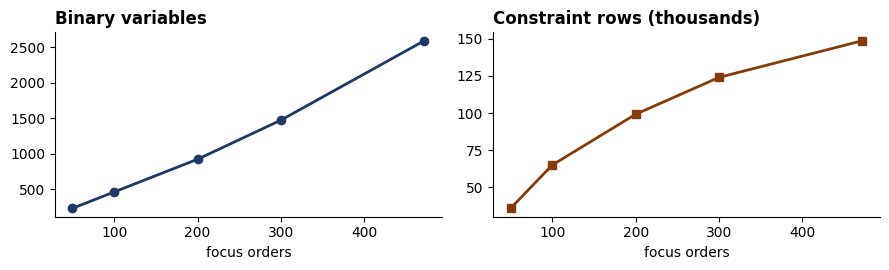

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(9, 2.8))
ax[0].plot(SZ.orders, SZ.binary_vars, "o-", color="#1f3864", lw=2)
ax[0].set_title("Binary variables", loc="left", fontweight="bold"); ax[0].set_xlabel("focus orders")
ax[1].plot(SZ.orders, SZ.rows / 1000, "s-", color="#833c0c", lw=2)
ax[1].set_title("Constraint rows (thousands)", loc="left", fontweight="bold")
ax[1].set_xlabel("focus orders")
for a in ax:
    a.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 14. What this tells us

* **The greedy is close in percent, but far in useful terms.** Most of the money sits in orders that
  were never in trouble. Measured against the gain that is actually reachable, the greedy leaves most
  of it behind.
* **The solver moves more orders than the greedy.** Because it plans all orders together it can
  connect moves: emptying one DC frees stock that lets a second order move in. A one-pass method
  cannot see that.
* **Time is not the problem here.** The whole set solves in about a minute, so the exact model is
  simply the better choice on this data. What grows first as the problem gets bigger is the number of
  binary variables, which is orders times candidate DCs.